In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("kerala_real_estate_geo_rebuilt.csv")

df.head()

,date,City/Place,district,urban_tier,country,property_type,furnishing_status,price,bedrooms,bathrooms,...,nearest_it_park_distance_km,nearest_airport_distance_km,nearest_bus_station_distance_km,nearest_mall_distance_km,school_rating,hospital_rating,crime_index,future_development_score,latitude,longitude
0,2023-10-30,Thrissur,Thiruvananthapuram,1,India,Independent House,Fully Furnished,46674571,6,5.0,...,38.8,58.8,3.6,24.3,5.6,8.9,6.3,3.3,8.544377,76.856801
1,2024-12-03,Kollam,Idukki,1,India,Apartment,Semi-Furnished,13681824,3,3.0,...,22.2,52.3,11.0,4.1,6.4,7.1,9.2,9.2,9.910036,77.045245
2,2023-09-20,Thiruvananthapuram,Palakkad,1,India,Villa,Unfurnished,13802015,3,3.0,...,43.0,58.6,0.4,4.1,3.4,9.0,8.6,2.3,10.623917,76.545826
3,2025-04-29,Kottayam,Ernakulam,1,India,Apartment,Semi-Furnished,11996888,3,3.0,...,35.0,33.8,11.5,29.9,5.5,8.5,7.9,5.2,9.990227,76.264701
4,2023-08-11,Thiruvananthapuram,Thrissur,1,India,Independent House,Semi-Furnished,22174093,4,4.0,...,5.2,63.2,11.7,20.3,5.9,4.3,6.1,8.9,10.518656,76.141756


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19330 entries, 0 to 19329
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             19330 non-null  object 
 1   City/Place                       19330 non-null  object 
 2   district                         19330 non-null  object 
 3   urban_tier                       19330 non-null  int64  
 4   country                          19330 non-null  object 
 5   property_type                    19330 non-null  object 
 6   furnishing_status                19330 non-null  object 
 7   price                            19330 non-null  int64  
 8   bedrooms                         19330 non-null  int64  
 9   bathrooms                        19330 non-null  float64
 10  floors                           19330 non-null  int64  
 11  sqft_living                      19330 non-null  int64  
 12  sqft_ground_floor 

In [3]:
df.drop('City/Place', axis=1, inplace=True)


In [4]:
df.drop('date', axis=1, inplace=True)


In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\niran\AppData\Local\Temp\ipykernel_6912\485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\niran\AppData\Local\Temp\ipykernel_6912\485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

# Outlier Detection

Visualize Outliers Using Boxplots

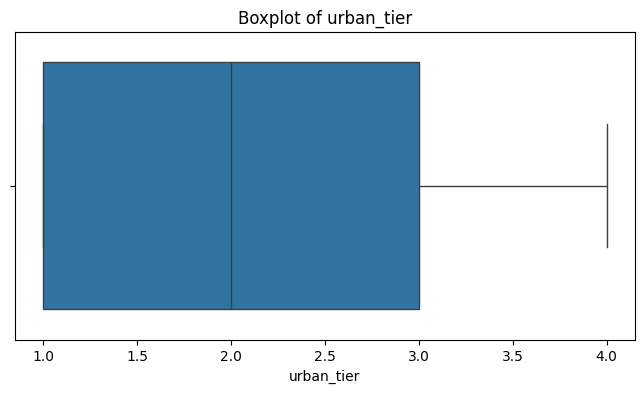

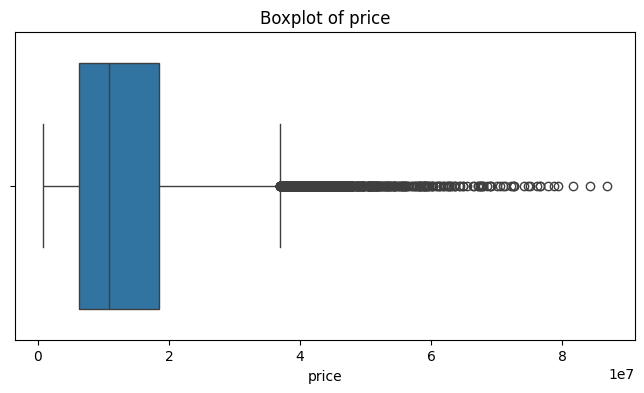

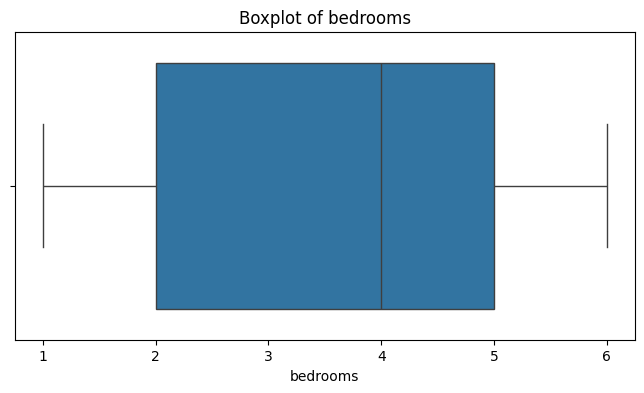

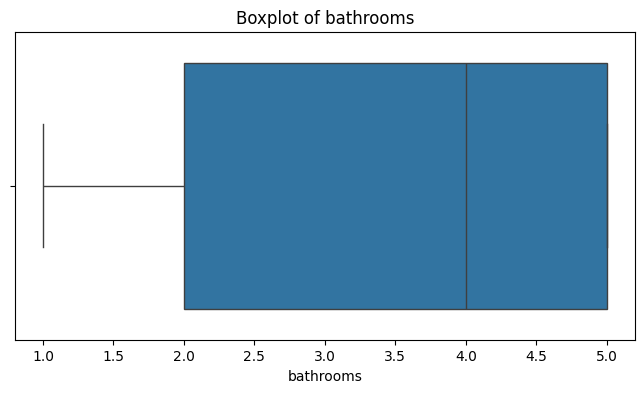

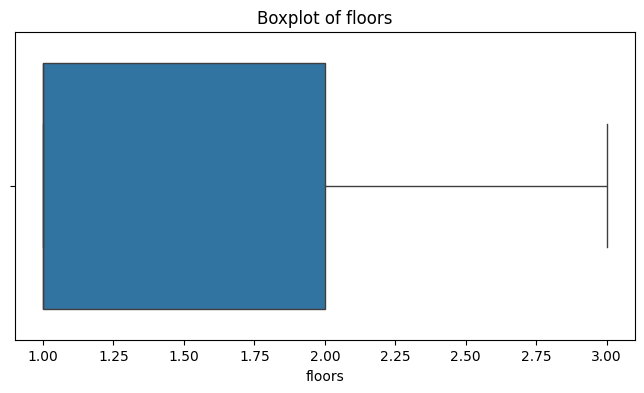

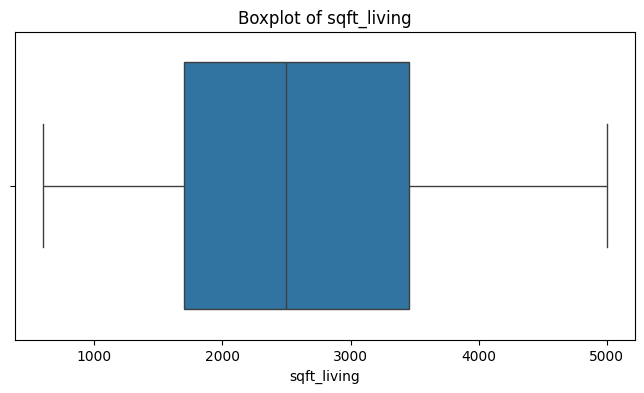

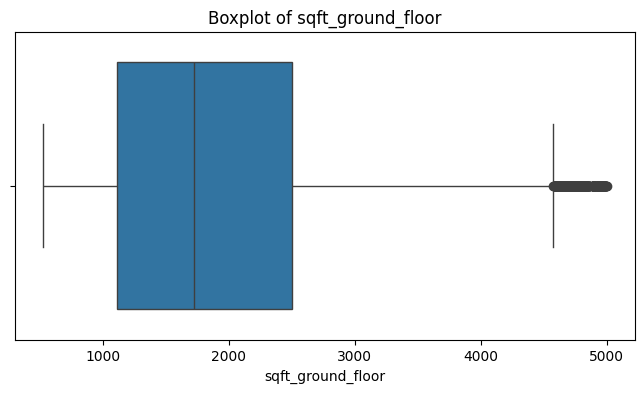

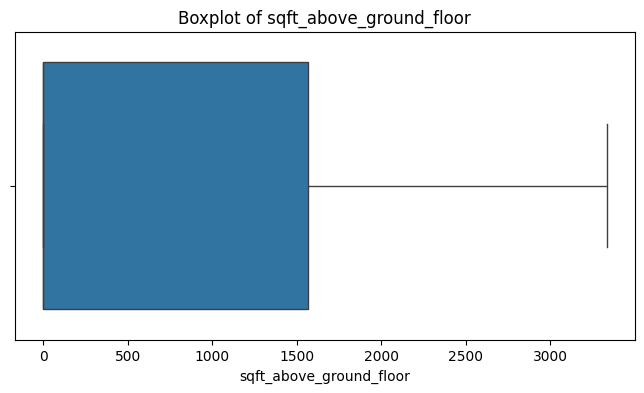

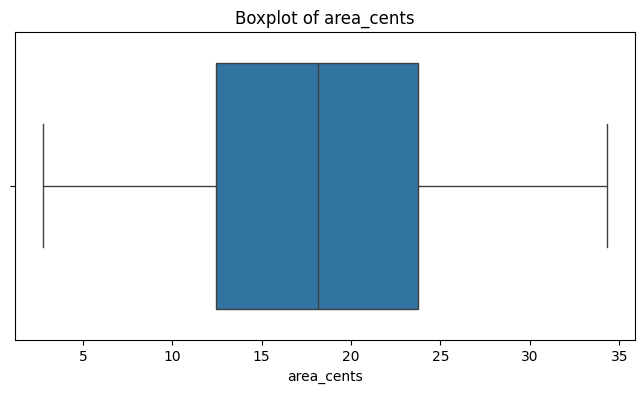

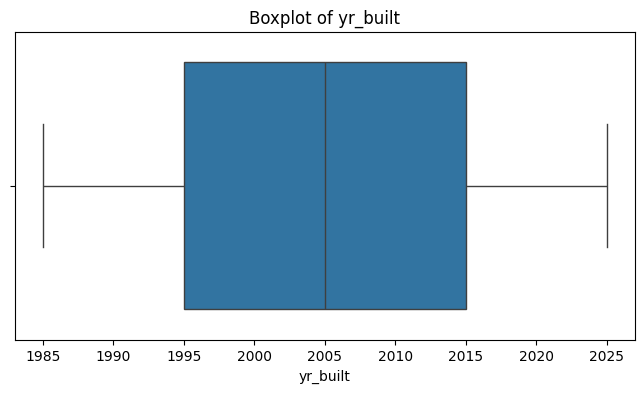

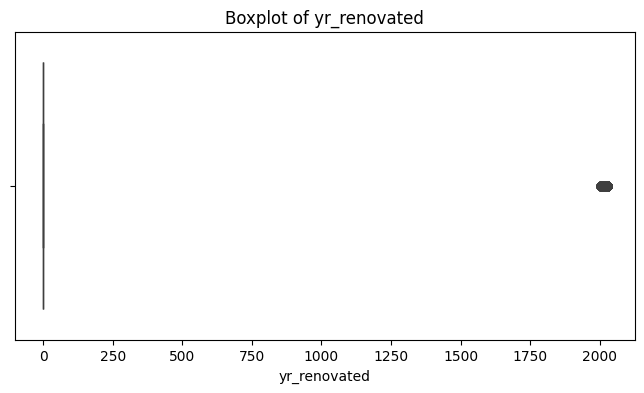

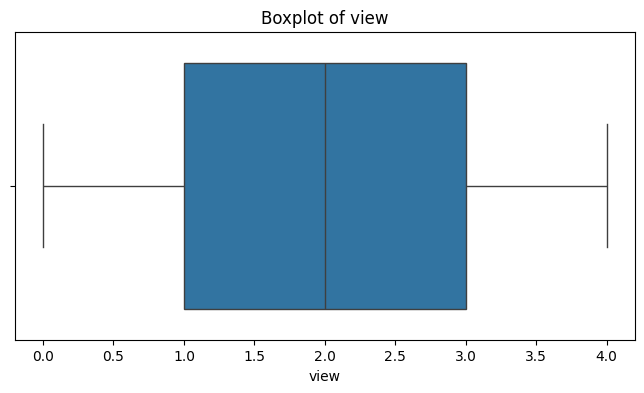

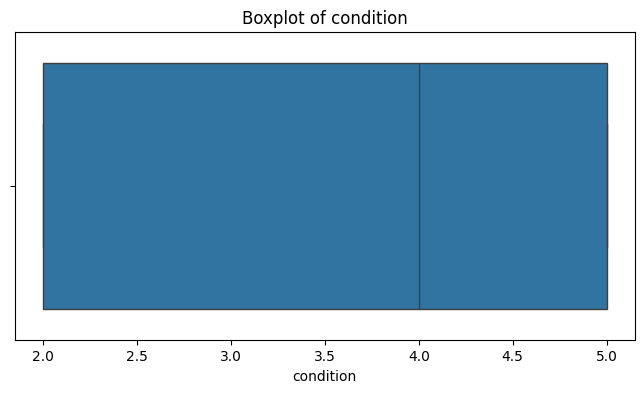

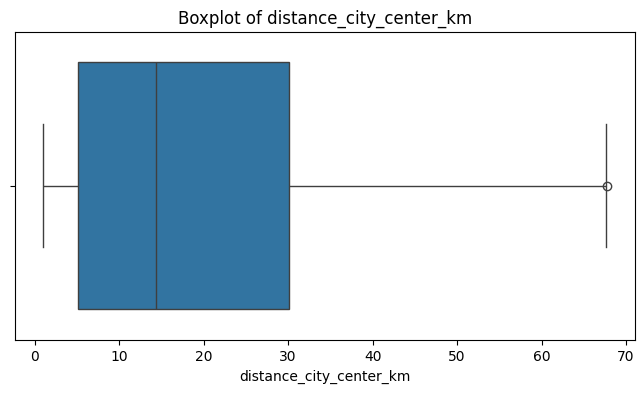

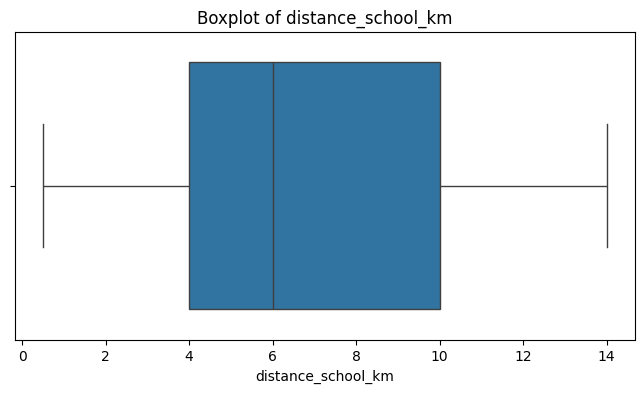

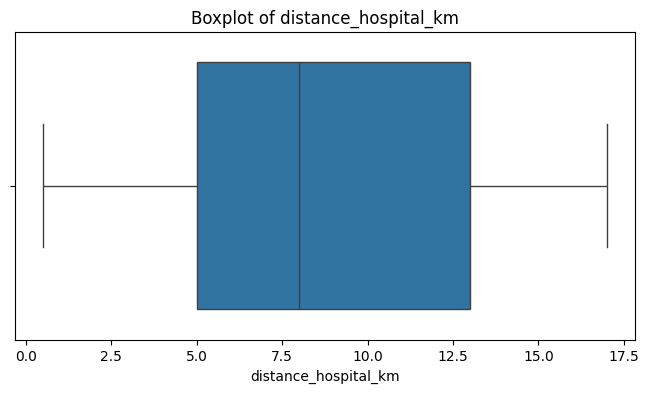

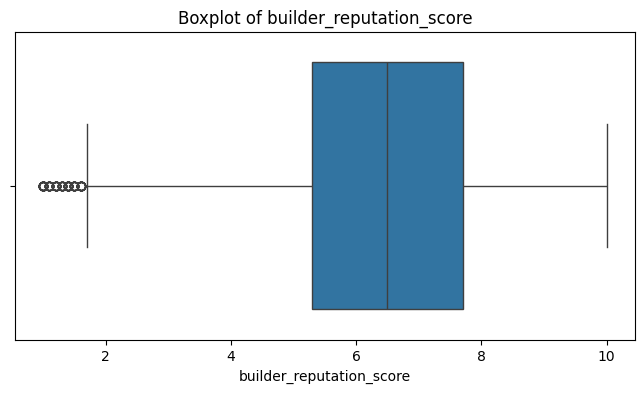

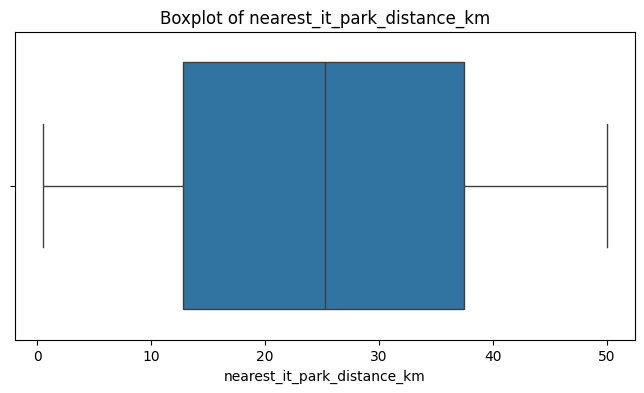

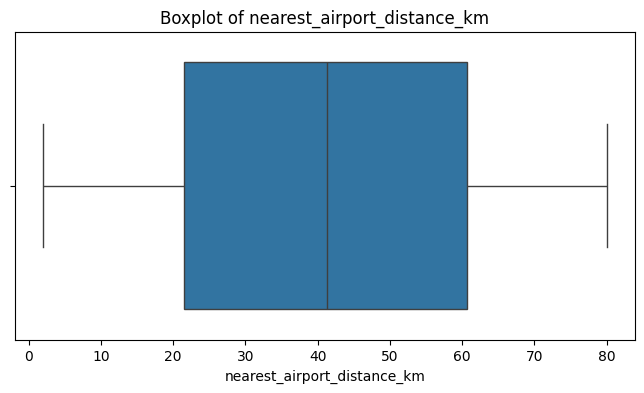

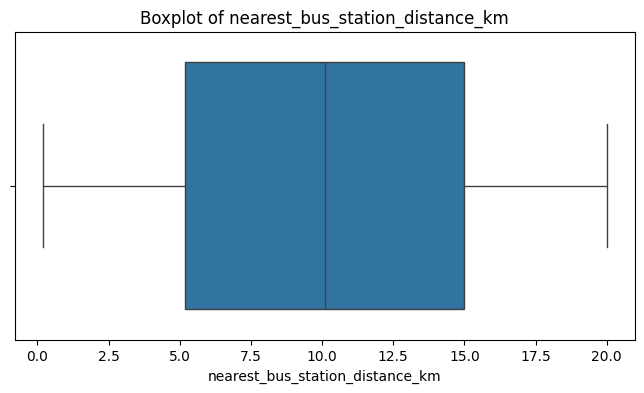

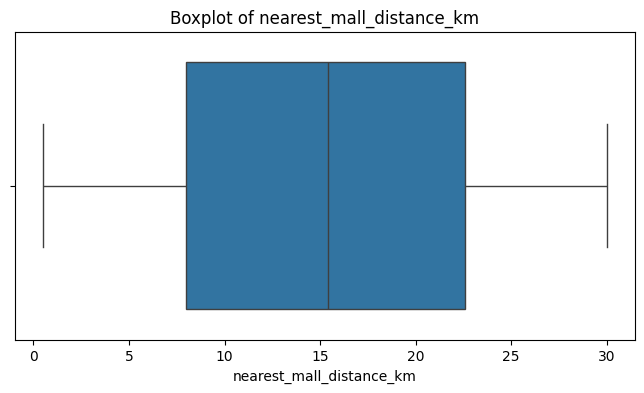

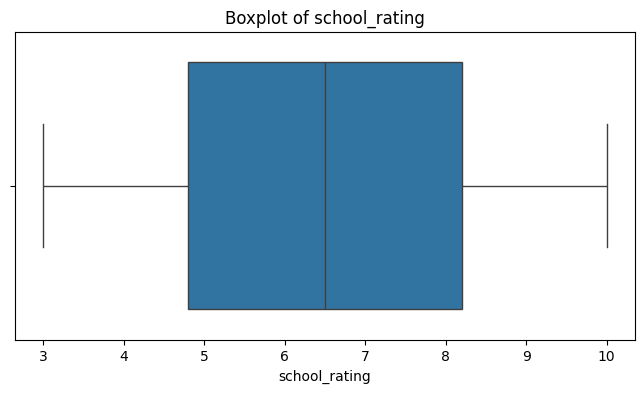

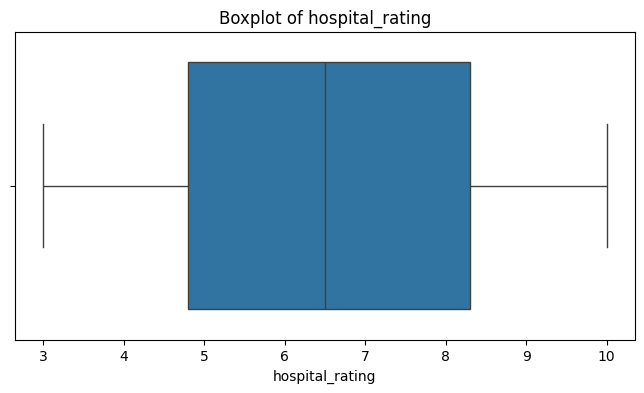

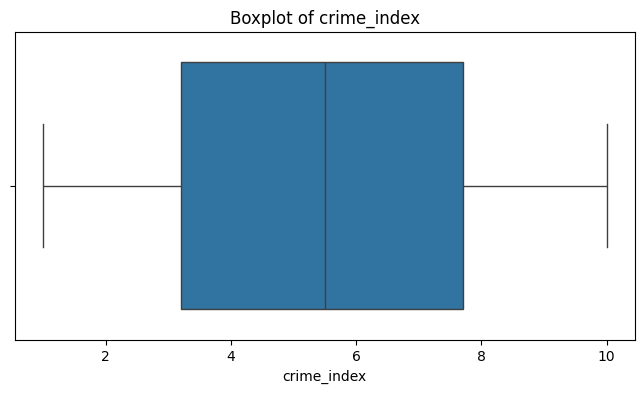

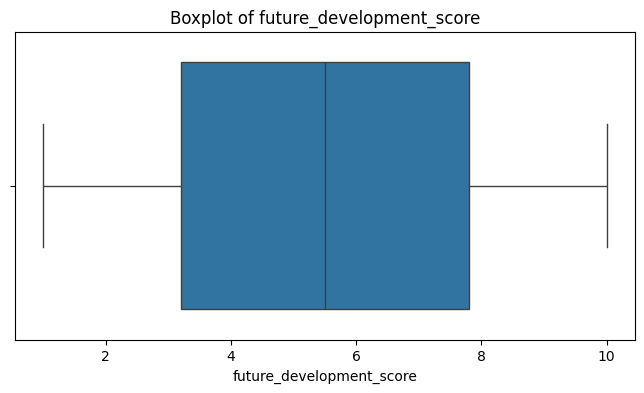

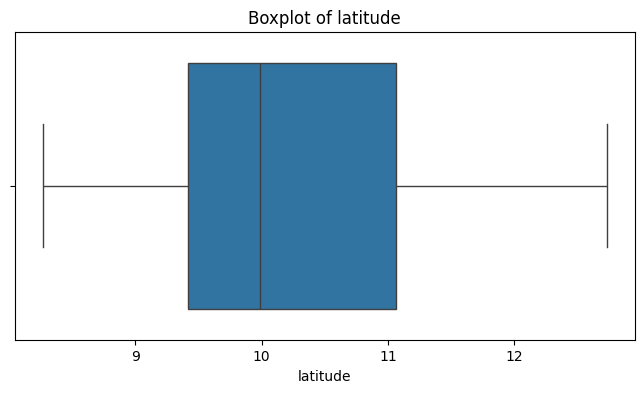

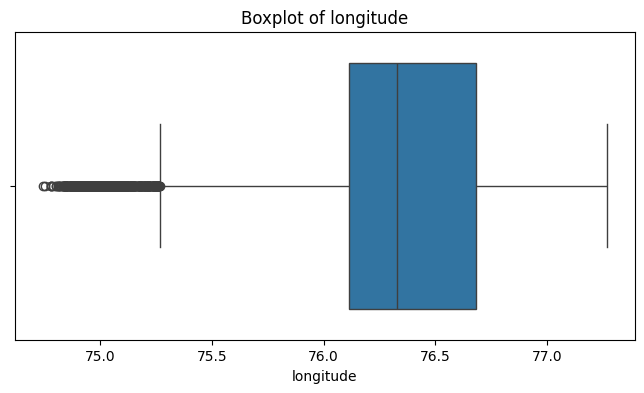

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    
    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

IQR Method

In [7]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    return lower, upper

Count Outliers

In [8]:
for col in num_cols:

    lower, upper = detect_outliers_iqr(df,col)

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        col,
        "Outliers:",
        len(outliers)
    )

urban_tier Outliers: 0
price Outliers: 745
bedrooms Outliers: 0
bathrooms Outliers: 0
floors Outliers: 0
sqft_living Outliers: 0
sqft_ground_floor Outliers: 298
sqft_above_ground_floor Outliers: 0
area_cents Outliers: 0
yr_built Outliers: 0
yr_renovated Outliers: 3019
view Outliers: 0
condition Outliers: 0
distance_city_center_km Outliers: 1
distance_school_km Outliers: 0
distance_hospital_km Outliers: 0
builder_reputation_score Outliers: 87
nearest_it_park_distance_km Outliers: 0
nearest_airport_distance_km Outliers: 0
nearest_bus_station_distance_km Outliers: 0
nearest_mall_distance_km Outliers: 0
school_rating Outliers: 0
hospital_rating Outliers: 0
crime_index Outliers: 0
future_development_score Outliers: 0
latitude Outliers: 0
longitude Outliers: 939


Treat Outliers (Winsorization)

In [9]:
for col in num_cols:

    lower, upper = detect_outliers_iqr(df,col)

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

Outliers Count after Treating

In [10]:
for col in num_cols:

    lower, upper = detect_outliers_iqr(df,col)

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        col,
        "Outliers:",
        len(outliers)
    )

urban_tier Outliers: 0
price Outliers: 0
bedrooms Outliers: 0
bathrooms Outliers: 0
floors Outliers: 0
sqft_living Outliers: 0
sqft_ground_floor Outliers: 0
sqft_above_ground_floor Outliers: 0
area_cents Outliers: 0
yr_built Outliers: 0
yr_renovated Outliers: 0
view Outliers: 0
condition Outliers: 0
distance_city_center_km Outliers: 0
distance_school_km Outliers: 0
distance_hospital_km Outliers: 0
builder_reputation_score Outliers: 0
nearest_it_park_distance_km Outliers: 0
nearest_airport_distance_km Outliers: 0
nearest_bus_station_distance_km Outliers: 0
nearest_mall_distance_km Outliers: 0
school_rating Outliers: 0
hospital_rating Outliers: 0
crime_index Outliers: 0
future_development_score Outliers: 0
latitude Outliers: 0
longitude Outliers: 0


In [11]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

## Visualization

Graph 1: Price Distribution

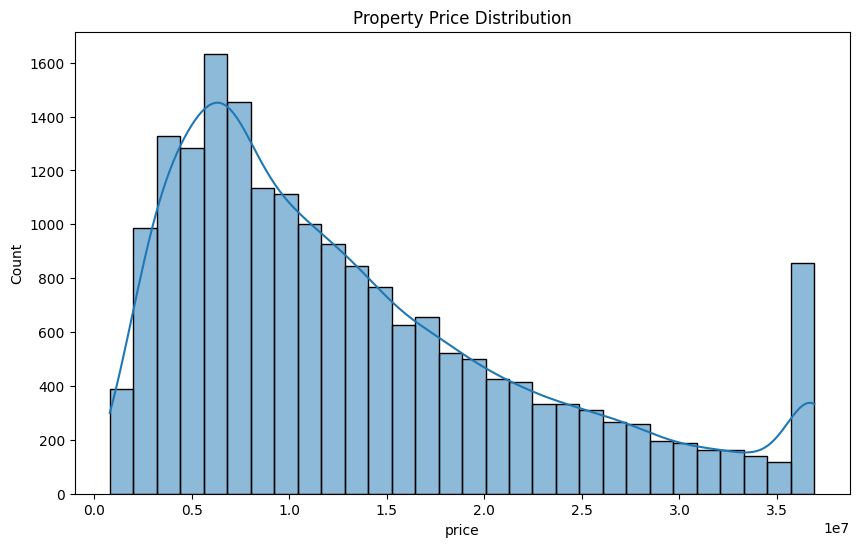

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Property Price Distribution")

plt.show()

Graph 2: Correlation Heatmap

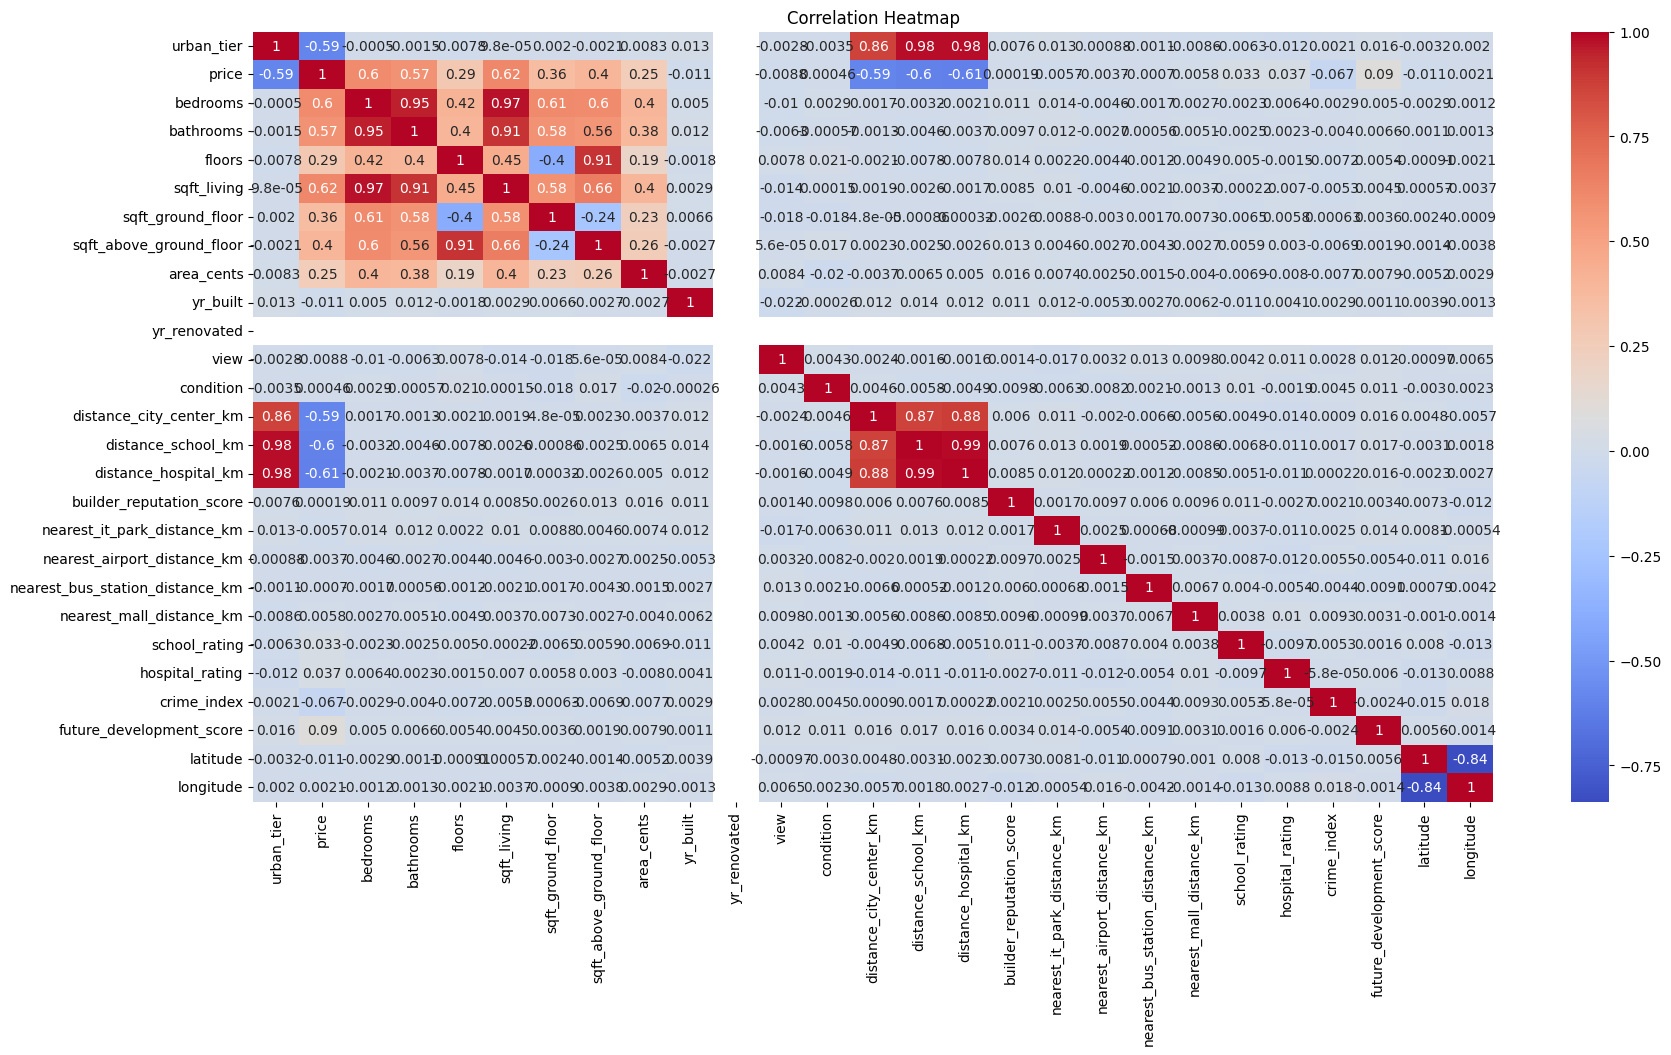

In [13]:
plt.figure(figsize=(20,10))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Graph 3: Price vs Square Feet

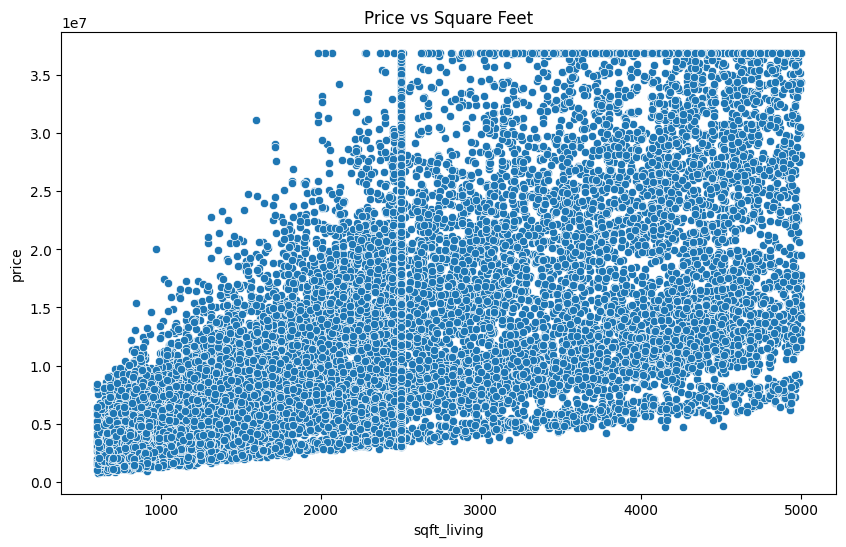

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["sqft_living"],
    y=df["price"]
)

plt.title("Price vs Square Feet")

plt.show()

Graph 4: Average Price by District

In [15]:
district_avg = (
    df.groupby("district")
    ["price"]
    .mean()
    .sort_values(ascending=False)
)

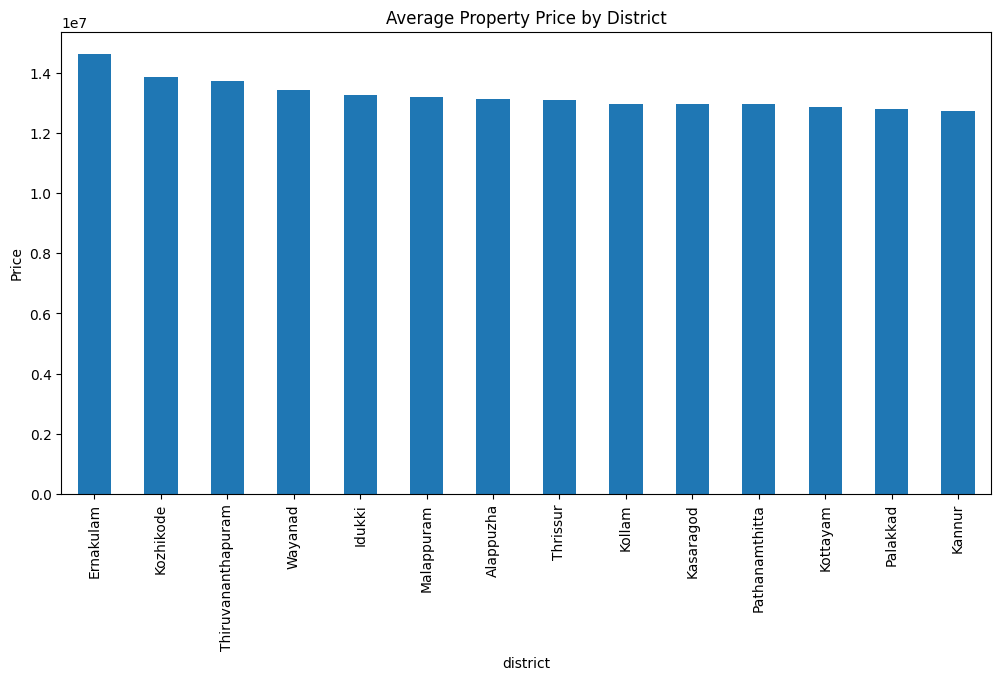

In [16]:
plt.figure(figsize=(12,6))

district_avg.plot(
    kind='bar'
)

plt.title(
    "Average Property Price by District"
)

plt.ylabel("Price")

plt.show()

Graph 5: Development Score vs Price

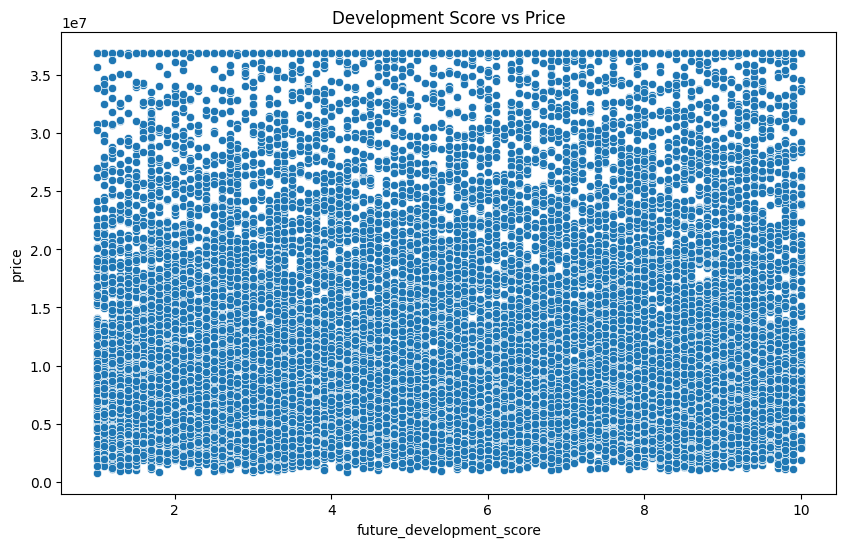

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["future_development_score"],
    y=df["price"]
)

plt.title(
    "Development Score vs Price"
)

plt.show()

In [18]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

In [19]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(X[col].astype(str))
    
    encoders[col] = le

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# pip install tensorflow

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

In [ ]:
# pip install numpy==1.26.4

: 

In [24]:
model = Sequential()

model.add(Dense(256,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(BatchNormalization())

model.add(Dropout(0.3))

model.add(Dense(128,
                activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(64,
                activation='relu'))

model.add(Dense(32,
                activation='relu'))

model.add(Dense(1))

C:\Users\niran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 211220166606848.0000 - mae: 11740705.0000 - val_loss: 36781323976704.0000 - val_mae: 4993728.0000
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27881791029248.0000 - mae: 4251106.5000 - val_loss: 19709797859328.0000 - val_mae: 3599146.2500
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 21811815251968.0000 - mae: 3644392.0000 - val_loss: 15510809870336.0000 - val_mae: 3049294.5000
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 19158741811200.0000 - mae: 3313694.7500 - val_loss: 14552600150016.0000 - val_mae: 2661373.2500
Epoch 5/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17643413176320.0000 - mae: 3038597.2500 - val_loss: 12784915972096.0000 - val_mae: 2486580.5000
Epoch 6/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17149969039360.0000 - mae: 2997432.7500 - val_loss: 12617661808640.0000 - val_mae: 2441967.0000
Epoch 7/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - l

In [28]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)

mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

print("R² Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("MSE      :", round(mse,2))
print("RMSE     :", round(rmse,2))

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R² Score : 0.858
MAE      : 2344550.03
MSE      : 12184661142858.44
RMSE     : 3490653.4


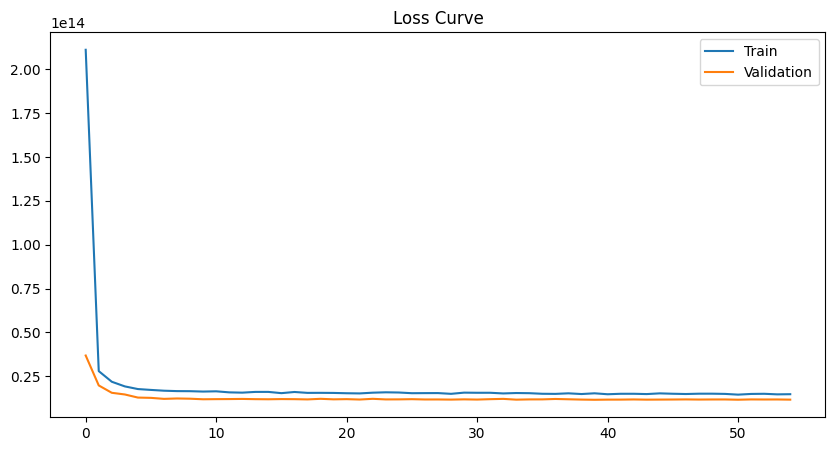

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Loss Curve")

plt.show()

In [30]:
# pip install shap

In [31]:
# import shap

# explainer = shap.Explainer(
#     model.predict,
#     X_train[:100]
# )

# shap_values = explainer(X_test[:50])

# shap.plots.beeswarm(shap_values)

In [32]:
model.save("best_model.keras")

import joblib

joblib.dump(scaler, "scaler.joblib")
joblib.dump(encoders, "encoders.joblib")
joblib.dump(X.columns.tolist(), "features.joblib")

default_features = {}
for col in X.columns:
    if col in encoders:
        mode_val = df[col].mode()[0]
        default_features[col] = mode_val
    else:
        default_features[col] = df[col].median()

joblib.dump(default_features, "default_features.joblib")
print("Saved scaler, encoders, features list, and default values successfully!")


Saved scaler, encoders, features list, and default values successfully!


In [33]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

pred = model.predict(X_test)

print(pred)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[[1.6557695e+07]
 [3.2448410e+07]
 [1.6340082e+06]
 ...
 [2.4496330e+07]
 [1.7091184e+07]
 [1.2376221e+07]]
